## Function Approximation Using Least Squares and Neural Networks

This notebook follows the coursework workflow:    
1.Load and explore the dataset  
2.Prepare training and validation data  
3.Fit a 4th-order polynomial least-squares baseline  
4.Train a feedforward neural network for regression  
5.Evaluate both models on the validation set  
6.Compare optimisation behaviour and generalisation

本 notebook 按照 coursework brief 的推荐流程完成两个模型：  
一个是四次多项式 least squares baseline，  
另一个是前馈神经网络回归模型，  
并比较它们的 optimisation behaviour、overfitting 和 generalisation。

If libraries are not installed correctly  
try %pip install numpy pandas matplotlib in a new code cell

## Step 1: Load and explore the dataset

#### Purpose  
- The purpose of this step is to understand the regression task before building any model.  
- First load the training and validation datasets, identify the input variable \(x\) and target variable \(y\), and visualise the data using scatter plots. 

#### Methodology
- The training and validation datasets are loaded from the provided CSV files.    
- The variables are extracted and stored in array form so that they can be used later in matrix computations for both polynomial regression and neural network training.  
- A scatter plot is used to inspect whether the relationship between \(x\) and \(y\) appears linear or nonlinear, and whether the data contains visible noise.



=== Dataset overview ===
Training set shape: (400, 2)
Validation set shape: (100, 2)

Training set head:
          x          y
0  1.095824   1.635425
1 -0.244486  -0.338836
2  1.434392   3.926012
3  0.789472  -0.027757
4 -1.623291  11.301925

Validation set head:
          x          y
0 -0.792290   0.380422
1  1.673768   6.860788
2  1.125176   1.614931
3 -1.557646   9.929234
4  1.988139  14.135489

Training summary statistics:
                x           y
count  400.000000  400.000000
mean    -0.013815    3.786131
std      1.140097    5.321142
min     -1.970551   -0.880020
25%     -1.040343    0.006840
50%     -0.034280    1.264769
75%      1.032783    6.678148
max      1.969502   23.986848

Validation summary statistics:
                x           y
count  100.000000  100.000000
mean    -0.031115    4.368830
std      1.180395    6.003807
min     -1.978281   -0.609834
25%     -1.145332    0.180854
50%      0.123767    1.466492
75%      0.864335    6.899558
max      1.996419   24.72

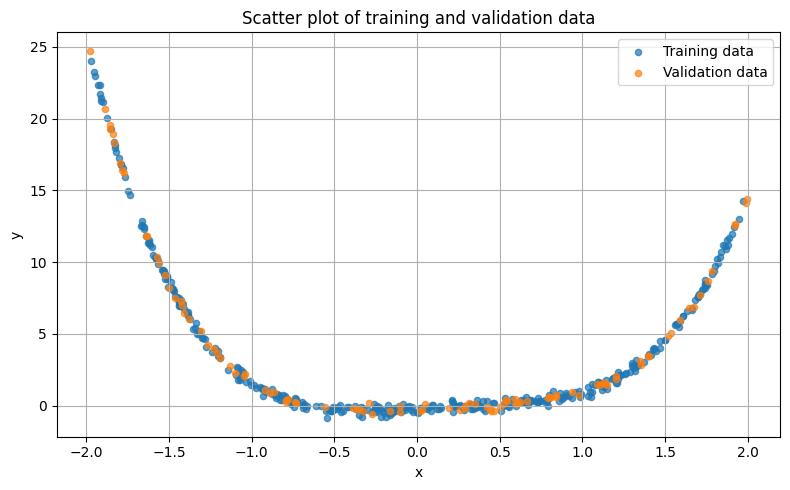

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv('train.csv')  #loads train dataset
val_df = pd.read_csv('val.csv') #loads validation dataset

#.to_numpy(dtype=float): converts the table into NumPy arrays for matrix operations.
#Why use [['x']] instead of ['x']
#Because:['x'] gives a 1D Series;[['x']] gives a 2D DataFrame
#Neural network code and matrix multiplication are easier and safer with shape (n,1).

x_train = train_df[['x']].to_numpy(dtype=float) #extracts the input variable x while keeping a 2D shape.
y_train = train_df[['y']].to_numpy(dtype=float) #extracts the target y
x_val = val_df[['x']].to_numpy(dtype=float)
y_val = val_df[['y']].to_numpy(dtype=float)

print('=== Dataset overview ===')
print('Training set shape:', train_df.shape)
print('Validation set shape:', val_df.shape)
print('\nTraining set head:')
print(train_df.head())
print('\nValidation set head:')
print(val_df.head())
print('\nTraining summary statistics:')
print(train_df.describe())
print('\nValidation summary statistics:')
print(val_df.describe())

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, s=20, alpha=0.7, label='Training data')
plt.scatter(x_val, y_val, s=20, alpha=0.7, label='Validation data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of training and validation data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Results and discussion
- The scatter plot suggests that the relationship between (x) and (y) is nonlinear, so a simple linear model would not be sufficient.  
- The points follow a smooth overall trend but do not lie exactly on a single curve, which indicates that noise is present in the observations.  
- The training and validation sets also appear to have a similar pattern, which suggests that they are sampled from the same underlying function.


## Step 2: Prepare training and validation data  

#### Purpose  
The purpose of this step is to prepare the data for model fitting while keeping the validation set independent for evaluation and model selection.

#### Methodology  
- The training set is used to fit model parameters, while the validation set is reserved for evaluation and generalisation analysis.  
- For the neural network, both input and target values are standardised using the mean and standard deviation of the training set only.  
- The same transformation is then applied to the validation set. This avoids data leakage and improves the stability of gradient-based optimisation.

#### Core
- After standardisation, the neural network is trained in a more numerically stable space, where the variables have comparable scales.  
- This is useful because gradient-based optimisation can be sensitive to the scale of inputs and targets.  
- Importantly, the validation set is not used to estimate the scaling statistics, so it remains independent from training.



In [ ]:
x_mean = x_train.mean(axis=0) # computes the mean of training inputs.
x_std = x_train.std(axis=0) #computes the standard deviation of training inputs.
y_mean = y_train.mean(axis=0) #computes the mean of training targets.
y_std = y_train.std(axis=0) #computes the standard deviation of training targets.

x_train_scaled = (x_train - x_mean) / x_std #standardises training inputs.
x_val_scaled = (x_val - x_mean) / x_std #standardises validation inputs using training statistics.
y_train_scaled = (y_train - y_mean) / y_std #standardises training targets.
y_val_scaled = (y_val - y_mean) / y_std #tandardises validation targets similarly. 

## Step 3: Least Squares 4th-order polynomial baseline  

#### Purpose
The purpose of this step is to build the classical baseline required by the coursework, so that it can later be compared with the neural network approach.

#### Methodology 
Transform the input $x$ into a feature matrix $X$ containing $[1, x, x^2, x^3, x^4]$. The parameters are solved analytically using the Normal Equation (via np.linalg.lstsq), which minimizes the Mean Squared Error (MSE).

In [12]:
def build_polynomial_features(x, degree=4):
    feature_list = [] #creates an empty list to store each feature column.
    for power in range(degree + 1): #loops from power 0 to 4.
        feature_list.append(x ** power) #appends x^0, x^1, x^2, x^3, x^4.
    return np.hstack(feature_list) #stacks those columns into one feature matrix.

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

X_train_poly = build_polynomial_features(x_train, degree=4)
X_val_poly = build_polynomial_features(x_val, degree=4)

poly_coefficients, residuals, rank, singular_values = np.linalg.lstsq(
    X_train_poly,
    y_train,
    rcond=None
)

poly_train_pred = X_train_poly @ poly_coefficients
poly_val_pred = X_val_poly @ poly_coefficients

poly_train_mse = mse(y_train, poly_train_pred)
poly_val_mse = mse(y_val, poly_val_pred)

print("Polynomial coefficients:")
for i, coef in enumerate(poly_coefficients.flatten()):
    print(f"a{i} = {coef:.6f}")
print("Training MSE:", poly_train_mse)
print("Validation MSE:", poly_val_mse)

Polynomial coefficients:
a0 = -0.214638
a1 = 0.507593
a2 = 0.289898
a3 = -0.803662
a4 = 1.205393
Training MSE: 0.0422503850793052
Validation MSE: 0.0307308080692366


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/1310468869.py:19: RuntimeWarning: divide by zero encountered in matmul
  poly_train_pred = X_train_poly @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/1310468869.py:19: RuntimeWarning: overflow encountered in matmul
  poly_train_pred = X_train_poly @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/1310468869.py:19: RuntimeWarning: invalid value encountered in matmul
  poly_train_pred = X_train_poly @ poly_coefficients


## Step 4: Neural Network Regression

#### Purpose  
To implement a flexible, non-linear neural network for regression and train it to approximate the unknown function.

#### Methodology 


In [ ]:
#Activation function
def relu(z):
    return np.maximum(0, z)

def drelu(z):
    return (z > 0).astype(float)

#Forward Pass
def forward_regression(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Y_hat = A1 @ W2 + b2

    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Y_hat": Y_hat
    }
    return Y_hat, cache

#Backpropagation
def backprop_regression(X, Y, W1, b1, W2, b2):
    n = X.shape[0]

    Y_hat, cache = forward_regression(X, W1, b1, W2, b2)
    Z1 = cache["Z1"]
    A1 = cache["A1"]

    dL_dYhat = 2.0 * (Y_hat - Y) / n

    dW2 = A1.T @ dL_dYhat
    db2 = np.sum(dL_dYhat, axis=0, keepdims=True)

    dA1 = dL_dYhat @ W2.T
    dZ1 = dA1 * drelu(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return gradients

def train_neural_network(
    x_train, y_train, x_val, y_val,
    hidden_units=20,
    learning_rate=0.01,
    iterations=3000,
    seed=42
):
    rng = np.random.default_rng(seed)

    input_dim = x_train.shape[1]
    output_dim = y_train.shape[1]

    W1 = rng.normal(loc=0.0, scale=0.1, size=(input_dim, hidden_units))
    b1 = np.zeros((1, hidden_units))

    W2 = rng.normal(loc=0.0, scale=0.1, size=(hidden_units, output_dim))
    b2 = np.zeros((1, output_dim))

    training_losses = []
    validation_losses = []

    best_validation_loss = np.inf
    best_parameters = None
    best_iteration = 0

    for step in range(iterations):
        gradients = backprop_regression(x_train, y_train, W1, b1, W2, b2)

        W1 = W1 - learning_rate * gradients["dW1"]
        b1 = b1 - learning_rate * gradients["db1"]
        W2 = W2 - learning_rate * gradients["dW2"]
        b2 = b2 - learning_rate * gradients["db2"]

        y_train_hat, _ = forward_regression(x_train, W1, b1, W2, b2)
        y_val_hat, _ = forward_regression(x_val, W1, b1, W2, b2)

        train_loss = mse(y_train, y_train_hat)
        val_loss = mse(y_val, y_val_hat)

        training_losses.append(train_loss)
        validation_losses.append(val_loss)

        if val_loss < best_validation_loss:
            best_validation_loss = val_loss
            best_parameters = (
                W1.copy(),
                b1.copy(),
                W2.copy(),
                b2.copy()
            )
            best_iteration = step + 1

    return {
        "best_parameters": best_parameters,
        "best_iteration": best_iteration,
        "best_validation_loss": best_validation_loss,
        "training_losses": training_losses,
        "validation_losses": validation_losses
    }

In [ ]:
hidden_unit_choices = [5, 10, 20, 50]

best_hidden_units = None
best_result = None
lowest_val_loss = np.inf

for hidden_units in hidden_unit_choices:
    result = train_neural_network(
        x_train_scaled,
        y_train_scaled,
        x_val_scaled,
        y_val_scaled,
        hidden_units=hidden_units,
        learning_rate=0.01,
        iterations=3000,
        seed=42
    )

    print(f"Hidden units = {hidden_units}")
    print(f"  Best validation MSE (scaled) = {float(result['best_validation_loss'])}")
    print(f"  Best iteration = {result['best_iteration']}")

    if result["best_validation_loss"] < lowest_val_loss:
        lowest_val_loss = result["best_validation_loss"]
        best_hidden_units = hidden_units
        best_result = result

best_parameters = best_result["best_parameters"]
best_iteration = best_result["best_iteration"]
best_training_losses = best_result["training_losses"]
best_validation_losses = best_result["validation_losses"]

print("\n=== Best Neural Network Setting ===")
print("Best hidden units:", best_hidden_units)
print("Best iteration:", best_iteration)
print("Best validation MSE (scaled):", float(lowest_val_loss))


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:10: RuntimeWarning: divide by zero encountered in matmul
  Y_hat = A1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:10: RuntimeWarning: overflow encountered in matmul
  Y_hat = A1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:10: RuntimeWarning: invalid value encountered in matmul
  Y_hat = A1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:29: RuntimeWarning: divide by zero encountered in matmul
  dW2 = A1.T @ dL_dYhat
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:29: RuntimeWarning: overflow encountered in matmul
  dW2 = A1.T @ dL_dYhat
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:29: RuntimeWarning: invalid value encountered in matmul
  dW2 = A1.T @ dL_dYhat
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykerne

Hidden units = 5
  Best validation MSE (scaled) = 0.07945207335800887
  Best iteration = 3000
Hidden units = 10
  Best validation MSE (scaled) = 0.0678315122203164
  Best iteration = 3000
Hidden units = 20
  Best validation MSE (scaled) = 0.06456549623169568
  Best iteration = 3000
Hidden units = 50
  Best validation MSE (scaled) = 0.06311615743103555
  Best iteration = 3000

=== Best Neural Network Setting ===
Best hidden units: 50
Best iteration: 3000
Best validation MSE (scaled): 0.06311615743103555


## Step 5: Evaluate model performance



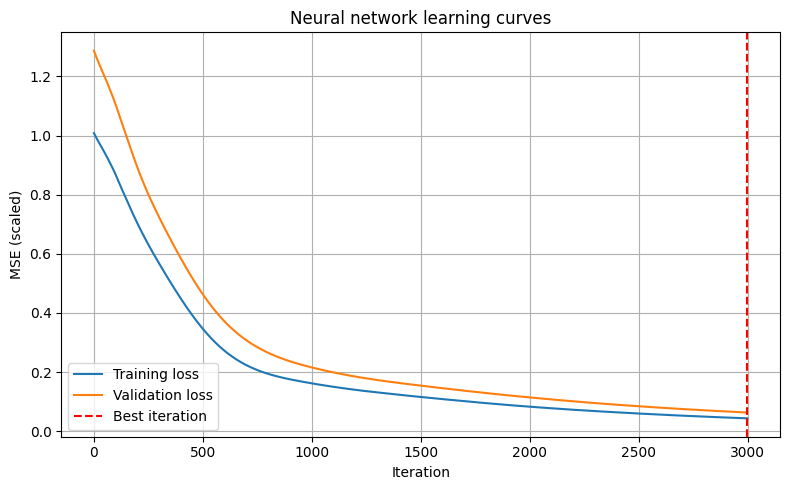

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(best_training_losses, label="Training loss")
plt.plot(best_validation_losses, label="Validation loss")
plt.axvline(best_iteration - 1, color="red", linestyle="--", label="Best iteration")
plt.xlabel("Iteration")
plt.ylabel("MSE (scaled)")
plt.title("Neural network learning curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
W1_best, b1_best, W2_best, b2_best = best_parameters

def unscale_y(y_scaled, y_mean, y_std):
    return y_scaled * y_std + y_mean

# Predictions in scaled space
y_train_pred_nn_scaled, _ = forward_regression(
    x_train_scaled, W1_best, b1_best, W2_best, b2_best
)
y_val_pred_nn_scaled, _ = forward_regression(
    x_val_scaled, W1_best, b1_best, W2_best, b2_best
)

# Convert back to original scale
y_train_pred_nn = unscale_y(y_train_pred_nn_scaled, y_mean, y_std)
y_val_pred_nn = unscale_y(y_val_pred_nn_scaled, y_mean, y_std)

nn_train_mse = mse(y_train, y_train_pred_nn)
nn_val_mse = mse(y_val, y_val_pred_nn)

print("\n=== Neural Network Results ===")
print("Neural Network training MSE (original scale):", float(nn_train_mse))
print("Neural Network validation MSE (original scale):", float(nn_val_mse))



=== Neural Network Results ===
Neural Network training MSE (original scale): 1.2283185947876623
Neural Network validation MSE (original scale): 1.7826381643970235


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:10: RuntimeWarning: divide by zero encountered in matmul
  Y_hat = A1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:10: RuntimeWarning: overflow encountered in matmul
  Y_hat = A1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:10: RuntimeWarning: invalid value encountered in matmul
  Y_hat = A1 @ W2 + b2


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/1273931398.py:8: RuntimeWarning: divide by zero encountered in matmul
  y_grid_poly = build_polynomial_features(x_grid, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/1273931398.py:8: RuntimeWarning: overflow encountered in matmul
  y_grid_poly = build_polynomial_features(x_grid, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/1273931398.py:8: RuntimeWarning: invalid value encountered in matmul
  y_grid_poly = build_polynomial_features(x_grid, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:10: RuntimeWarning: divide by zero encountered in matmul
  Y_hat = A1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/2357404246.py:10: RuntimeWarning: overflow encountered in matmul
  Y_hat = A1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/i

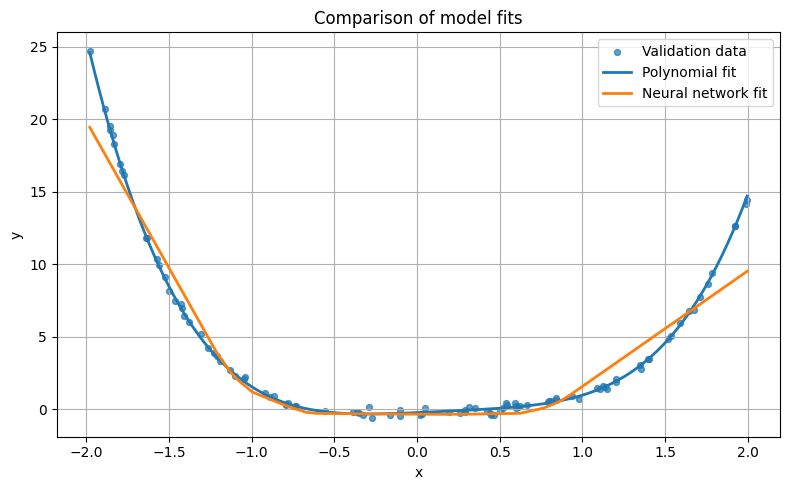

In [17]:
x_grid = np.linspace(
    min(train_df["x"].min(), val_df["x"].min()),
    max(train_df["x"].max(), val_df["x"].max()),
    400
).reshape(-1, 1)

# Polynomial fit on original scale
y_grid_poly = build_polynomial_features(x_grid, degree=4) @ poly_coefficients

# Neural network fit: scale x first, then unscale y
x_grid_scaled = (x_grid - x_mean) / x_std
y_grid_nn_scaled, _ = forward_regression(
    x_grid_scaled, W1_best, b1_best, W2_best, b2_best
)
y_grid_nn = unscale_y(y_grid_nn_scaled, y_mean, y_std)

plt.figure(figsize=(8, 5))
plt.scatter(x_val, y_val, s=18, alpha=0.7, label="Validation data")
plt.plot(x_grid, y_grid_poly, linewidth=2, label="Polynomial fit")
plt.plot(x_grid, y_grid_nn, linewidth=2, label="Neural network fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of model fits")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



## Step 6: Analyse and compare the approaches


In [18]:
poly_train_pred_original = build_polynomial_features(x_train, degree=4) @ poly_coefficients
poly_val_pred_original = build_polynomial_features(x_val, degree=4) @ poly_coefficients

poly_train_mse_original = mse(y_train, poly_train_pred_original)
poly_val_mse_original = mse(y_val, poly_val_pred_original)

nn_train_mse_original = mse(y_train, y_train_pred_nn)
nn_val_mse_original = mse(y_val, y_val_pred_nn)

comparison_df = pd.DataFrame({
    "Model": ["Least Squares Polynomial", "Neural Network"],
    "Training MSE": [
        float(poly_train_mse_original),
        float(nn_train_mse_original)
    ],
    "Validation MSE": [
        float(poly_val_mse_original),
        float(nn_val_mse_original)
    ],
    "Generalisation Gap": [
        float(poly_val_mse_original - poly_train_mse_original),
        float(nn_val_mse_original - nn_train_mse_original)
    ]
})

print("\n=== Final Comparison ===")
print(comparison_df)


=== Final Comparison ===
                      Model  Training MSE  Validation MSE  Generalisation Gap
0  Least Squares Polynomial      0.042250        0.030731            -0.01152
1            Neural Network      1.228319        1.782638             0.55432


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/1311756097.py:1: RuntimeWarning: divide by zero encountered in matmul
  poly_train_pred_original = build_polynomial_features(x_train, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/1311756097.py:1: RuntimeWarning: overflow encountered in matmul
  poly_train_pred_original = build_polynomial_features(x_train, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_40051/1311756097.py:1: RuntimeWarning: invalid value encountered in matmul
  poly_train_pred_original = build_polynomial_features(x_train, degree=4) @ poly_coefficients
